# IPL Raw Cricsheet EDA

This notebook explores the raw files under `data/ipl_csv2/`.

It covers two sources:
- match ball-by-ball CSV files
- `_info.csv` metadata files


In [1]:
from pathlib import Path
import csv

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('ggplot')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 200)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')


In [2]:
ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
RAW_DIR = ROOT / 'data' / 'ipl_csv2'

match_files = sorted([p for p in RAW_DIR.glob('*.csv') if not p.name.endswith('_info.csv')])
info_files = sorted(RAW_DIR.glob('*_info.csv'))

print('raw directory:', RAW_DIR)
print('match csv files:', len(match_files))
print('info csv files:', len(info_files))


raw directory: C:\Users\rahul\Documents\code\projects\ipl prediction\data\ipl_csv2
match csv files: 1172
info csv files: 1172


## Inspect One Match File

In [3]:
match_sample = pd.read_csv(match_files[0], low_memory=False)
print('sample match file:', match_files[0].name)
print('shape:', match_sample.shape)
match_sample.head()

sample match file: 1082591.csv
shape: (248, 22)


,match_id,season,start_date,venue,innings,ball,batting_team,bowling_team,striker,non_striker,bowler,runs_off_bat,extras,wides,noballs,byes,legbyes,penalty,wicket_type,player_dismissed,other_wicket_type,other_player_dismissed
0,1082591,2017,2017-04-05,"Rajiv Gandhi International Stadium, Uppal",1,0.100,Sunrisers Hyderabad,Royal Challengers Bangalore,DA Warner,S Dhawan,TS Mills,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1082591,2017,2017-04-05,"Rajiv Gandhi International Stadium, Uppal",1,0.200,Sunrisers Hyderabad,Royal Challengers Bangalore,DA Warner,S Dhawan,TS Mills,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1082591,2017,2017-04-05,"Rajiv Gandhi International Stadium, Uppal",1,0.300,Sunrisers Hyderabad,Royal Challengers Bangalore,DA Warner,S Dhawan,TS Mills,4,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1082591,2017,2017-04-05,"Rajiv Gandhi International Stadium, Uppal",1,0.400,Sunrisers Hyderabad,Royal Challengers Bangalore,DA Warner,S Dhawan,TS Mills,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1082591,2017,2017-04-05,"Rajiv Gandhi International Stadium, Uppal",1,0.500,Sunrisers Hyderabad,Royal Challengers Bangalore,DA Warner,S Dhawan,TS Mills,0,2,2.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
match_sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 248 entries, 0 to 247
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   match_id                248 non-null    int64  
 1   season                  248 non-null    int64  
 2   start_date              248 non-null    object 
 3   venue                   248 non-null    object 
 4   innings                 248 non-null    int64  
 5   ball                    248 non-null    float64
 6   batting_team            248 non-null    object 
 7   bowling_team            248 non-null    object 
 8   striker                 248 non-null    object 
 9   non_striker             248 non-null    object 
 10  bowler                  248 non-null    object 
 11  runs_off_bat            248 non-null    int64  
 12  extras                  248 non-null    int64  
 13  wides                   8 non-null      float64
 14  noballs                 2 non-null      fl

## Inspect One Info File

In [5]:
info_sample_path = info_files[0]
rows = []
with open(info_sample_path, newline='', encoding='utf-8') as f:
    for i, row in enumerate(csv.reader(f)):
        rows.append(row)
        if i >= 24:
            break

print('sample info file:', info_sample_path.name)
pd.DataFrame(rows)

sample info file: 1082591_info.csv


,0,1,2,3
0,version,2.1.0,None,None
1,info,balls_per_over,6,None
2,info,team,Sunrisers Hyderabad,None
3,info,team,Royal Challengers Bangalore,None
4,info,gender,male,None
5,info,season,2017,None
6,info,date,2017/04/05,None
7,info,event,Indian Premier League,None
8,info,match_number,1,None
9,info,venue,"Rajiv Gandhi International Stadium, Uppal",None


## Match-File Summary Table

In [6]:
match_summary_rows = []
for p in match_files:
    m = pd.read_csv(p, usecols=['season', 'venue', 'innings', 'ball', 'batting_team', 'bowling_team'], low_memory=False)
    match_summary_rows.append({
        'match_id': p.stem,
        'rows': len(m),
        'season': str(m['season'].iloc[0]) if not m.empty else None,
        'venue': str(m['venue'].iloc[0]) if not m.empty else None,
        'batting_team_first': str(m['batting_team'].iloc[0]) if not m.empty else None,
        'bowling_team_first': str(m['bowling_team'].iloc[0]) if not m.empty else None,
        'innings_max': int(pd.to_numeric(m['innings'], errors='coerce').max()) if not m.empty else None,
    })

match_summary = pd.DataFrame(match_summary_rows)
match_summary.head()

,match_id,rows,season,venue,batting_team_first,bowling_team_first,innings_max
0,1082591,248,2017,"Rajiv Gandhi International Stadium, Uppal",Sunrisers Hyderabad,Royal Challengers Bangalore,2
1,1082592,247,2017,Maharashtra Cricket Association Stadium,Mumbai Indians,Rising Pune Supergiant,2
2,1082593,218,2017,Saurashtra Cricket Association Stadium,Gujarat Lions,Kolkata Knight Riders,2
3,1082594,247,2017,Holkar Cricket Stadium,Rising Pune Supergiant,Kings XI Punjab,2
4,1082595,248,2017,M.Chinnaswamy Stadium,Royal Challengers Bangalore,Delhi Daredevils,2


In [7]:
match_overview = pd.Series({
    'match_files': len(match_summary),
    'raw_rows_total': int(match_summary['rows'].sum()),
    'avg_rows_per_match': match_summary['rows'].mean(),
    'median_rows_per_match': match_summary['rows'].median(),
    'min_rows_per_match': match_summary['rows'].min(),
    'max_rows_per_match': match_summary['rows'].max(),
    'season_count': match_summary['season'].nunique(),
    'venue_count': match_summary['venue'].nunique(),
})
match_overview

match_files               1,172.000
raw_rows_total          278,876.000
avg_rows_per_match          237.949
median_rows_per_match       245.000
min_rows_per_match           51.000
max_rows_per_match          269.000
season_count                 19.000
venue_count                  59.000
dtype: float64

In [8]:
match_summary['rows'].describe()

count   1,172.000
mean      237.949
std        22.501
min        51.000
25%       236.000
50%       245.000
75%       249.000
max       269.000
Name: rows, dtype: float64

## Raw Match Coverage by Season and Venue

In [9]:
season_match_counts = match_summary['season'].value_counts().sort_index()
venue_match_counts = match_summary['venue'].value_counts().head(15)

display(season_match_counts.to_frame('matches'))
display(venue_match_counts.to_frame('matches'))

,matches
season,
2007/08,58
2009,57
2009/10,60
2011,73
2012,74
2013,76
2014,60
2015,59
2016,60


,matches
venue,
Eden Gardens,77
Wankhede Stadium,73
M Chinnaswamy Stadium,65
Feroz Shah Kotla,60
"Wankhede Stadium, Mumbai",53
"Rajiv Gandhi International Stadium, Uppal",49
"MA Chidambaram Stadium, Chepauk",48
Sawai Mansingh Stadium,47
Dubai International Cricket Stadium,46


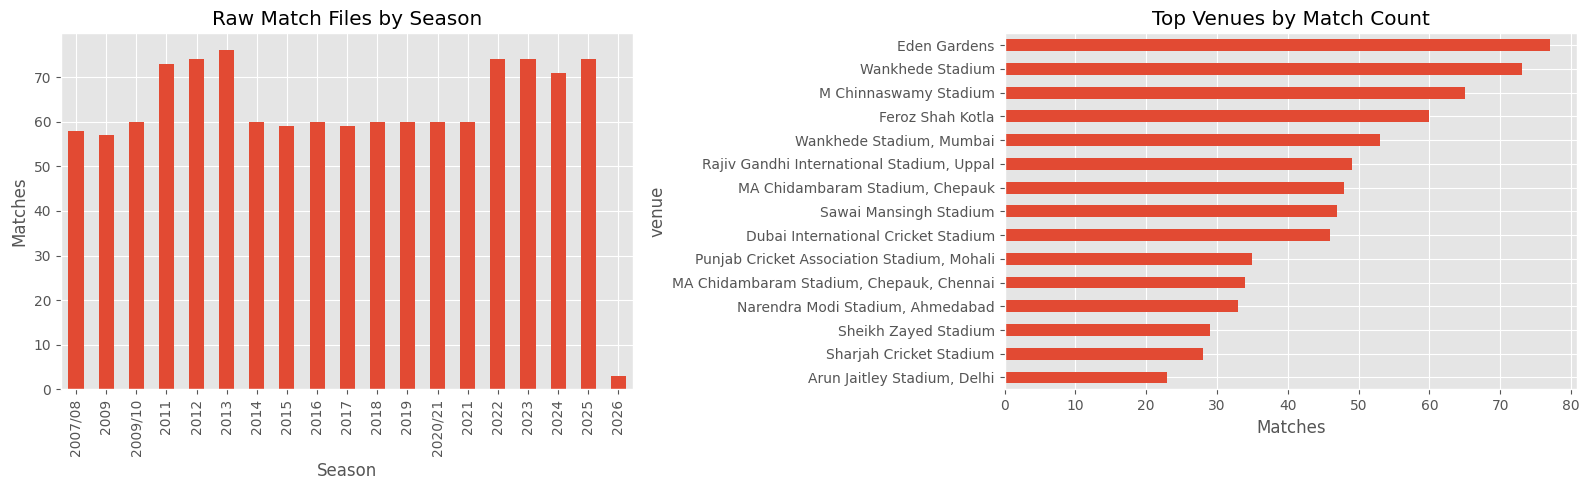

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
season_match_counts.plot(kind='bar', ax=axes[0], title='Raw Match Files by Season')
venue_match_counts.sort_values().plot(kind='barh', ax=axes[1], title='Top Venues by Match Count')
axes[0].set_xlabel('Season')
axes[0].set_ylabel('Matches')
axes[1].set_xlabel('Matches')
plt.tight_layout()

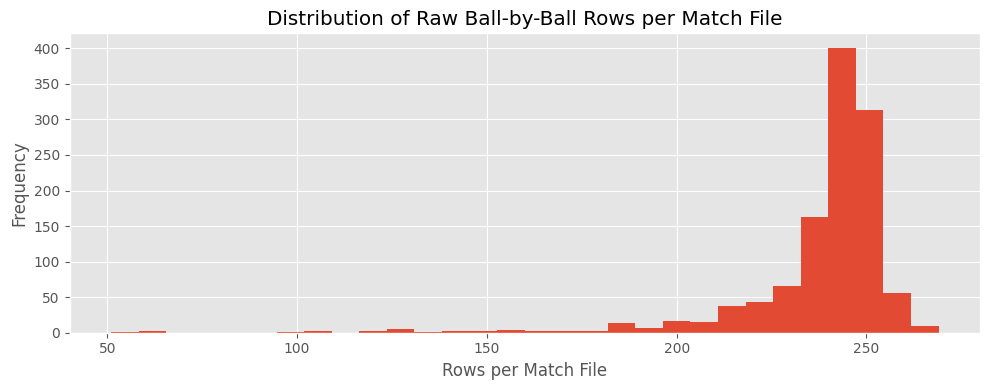

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))
match_summary['rows'].plot(kind='hist', bins=30, ax=ax, title='Distribution of Raw Ball-by-Ball Rows per Match File')
ax.set_xlabel('Rows per Match File')
plt.tight_layout()

## Info-File Metadata Extraction

In [12]:
info_records = []
for p in info_files:
    rec = {'match_id': p.stem.replace('_info', '')}
    team_list = []
    date_list = []
    with open(p, newline='', encoding='utf-8') as f:
        for row in csv.reader(f):
            if len(row) < 3 or row[0] != 'info':
                continue
            key = row[1]
            value = row[2]
            if key == 'team':
                team_list.append(value)
            elif key == 'date':
                date_list.append(value)
            else:
                rec[key] = value
    rec['team_1'] = team_list[0] if len(team_list) > 0 else None
    rec['team_2'] = team_list[1] if len(team_list) > 1 else None
    rec['start_date'] = date_list[0] if date_list else None
    info_records.append(rec)

info_df = pd.DataFrame(info_records)
info_df['start_date'] = pd.to_datetime(info_df['start_date'], errors='coerce')
info_df.head()

,match_id,balls_per_over,gender,season,event,match_number,venue,city,toss_winner,toss_decision,player_of_match,umpire,reserve_umpire,tv_umpire,match_referee,winner,winner_runs,player,registry,team_1,team_2,start_date,winner_wickets,outcome,eliminator,method
0,1082591,6,male,2017,Indian Premier League,1,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Royal Challengers Bangalore,field,Yuvraj Singh,NJ Llong,N Pandit,A Deshmukh,J Srinath,Sunrisers Hyderabad,35,Sunrisers Hyderabad,people,Sunrisers Hyderabad,Royal Challengers Bangalore,2017-04-05,NaN,NaN,NaN,NaN
1,1082592,6,male,2017,Indian Premier League,2,Maharashtra Cricket Association Stadium,Pune,Rising Pune Supergiant,field,SPD Smith,S Ravi,Navdeep Singh,VK Sharma,M Nayyar,Rising Pune Supergiant,NaN,Rising Pune Supergiant,people,Rising Pune Supergiant,Mumbai Indians,2017-04-06,7,NaN,NaN,NaN
2,1082593,6,male,2017,Indian Premier League,3,Saurashtra Cricket Association Stadium,Rajkot,Kolkata Knight Riders,field,CA Lynn,CK Nandan,K Srinivasan,YC Barde,V Narayan Kutty,Kolkata Knight Riders,NaN,Kolkata Knight Riders,people,Gujarat Lions,Kolkata Knight Riders,2017-04-07,10,NaN,NaN,NaN
3,1082594,6,male,2017,Indian Premier League,4,Holkar Cricket Stadium,Indore,Kings XI Punjab,field,GJ Maxwell,C Shamshuddin,R Pandit,KN Ananthapadmanabhan,Chinmay Sharma,Kings XI Punjab,NaN,Rising Pune Supergiant,people,Kings XI Punjab,Rising Pune Supergiant,2017-04-08,6,NaN,NaN,NaN
4,1082595,6,male,2017,Indian Premier League,5,M.Chinnaswamy Stadium,Bengaluru,Royal Challengers Bangalore,bat,KM Jadhav,VK Sharma,Navdeep Singh,A Nand Kishore,J Srinath,Royal Challengers Bangalore,15,Delhi Daredevils,people,Royal Challengers Bangalore,Delhi Daredevils,2017-04-08,NaN,NaN,NaN,NaN


In [13]:
info_overview = pd.Series({
    'info_files': len(info_df),
    'date_min': info_df['start_date'].min(),
    'date_max': info_df['start_date'].max(),
    'venue_count': info_df['venue'].nunique(),
    'city_count': info_df['city'].nunique(),
    'winner_nulls': int(info_df['winner'].isna().sum()) if 'winner' in info_df.columns else np.nan,
    'toss_field_pct': 100 * (info_df['toss_decision'] == 'field').mean(),
})
info_overview

info_files                       1172
date_min          2008-04-18 00:00:00
date_max          2026-03-30 00:00:00
venue_count                        59
city_count                         38
winner_nulls                       23
toss_field_pct                 65.444
dtype: object

In [14]:
display(info_df['toss_decision'].value_counts(dropna=False).to_frame('matches'))
display(info_df['venue'].value_counts().head(15).to_frame('matches'))
display(info_df['winner'].isna().value_counts().rename(index={False: 'winner_present', True: 'winner_missing'}).to_frame('matches'))

,matches
toss_decision,
field,767
bat,405


,matches
venue,
Eden Gardens,77
Wankhede Stadium,73
M Chinnaswamy Stadium,65
Feroz Shah Kotla,60
"Wankhede Stadium, Mumbai",53
"Rajiv Gandhi International Stadium, Uppal",49
"MA Chidambaram Stadium, Chepauk",48
Sawai Mansingh Stadium,47
Dubai International Cricket Stadium,46


,matches
winner,
winner_present,1149
winner_missing,23


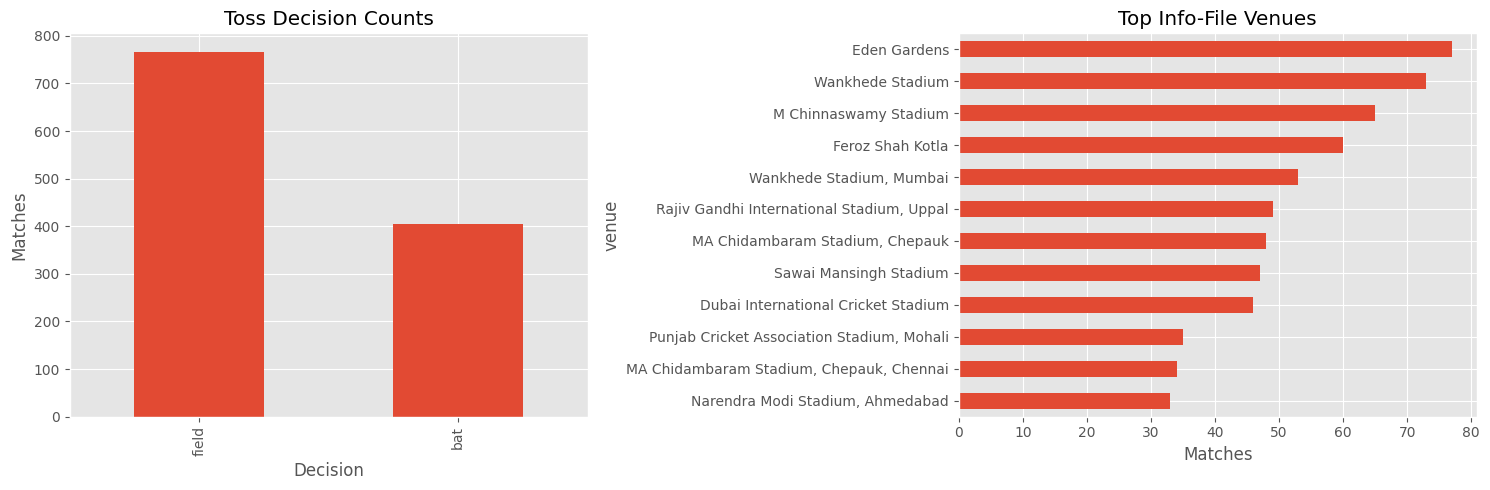

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
info_df['toss_decision'].value_counts().plot(kind='bar', ax=axes[0], title='Toss Decision Counts')
info_df['venue'].value_counts().head(12).sort_values().plot(kind='barh', ax=axes[1], title='Top Info-File Venues')
axes[0].set_xlabel('Decision')
axes[0].set_ylabel('Matches')
axes[1].set_xlabel('Matches')
plt.tight_layout()

## Merge Raw Match Summary With Info Metadata

In [16]:
raw_merged = match_summary.merge(
    info_df[['match_id', 'venue', 'city', 'season', 'team_1', 'team_2', 'winner', 'toss_winner', 'toss_decision', 'start_date']],
    on='match_id',
    how='left',
    suffixes=('_ball', '_info')
)
raw_merged.head()

,match_id,rows,season_ball,venue_ball,batting_team_first,bowling_team_first,innings_max,venue_info,city,season_info,team_1,team_2,winner,toss_winner,toss_decision,start_date
0,1082591,248,2017,"Rajiv Gandhi International Stadium, Uppal",Sunrisers Hyderabad,Royal Challengers Bangalore,2,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,2017,Sunrisers Hyderabad,Royal Challengers Bangalore,Sunrisers Hyderabad,Royal Challengers Bangalore,field,2017-04-05
1,1082592,247,2017,Maharashtra Cricket Association Stadium,Mumbai Indians,Rising Pune Supergiant,2,Maharashtra Cricket Association Stadium,Pune,2017,Rising Pune Supergiant,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,2017-04-06
2,1082593,218,2017,Saurashtra Cricket Association Stadium,Gujarat Lions,Kolkata Knight Riders,2,Saurashtra Cricket Association Stadium,Rajkot,2017,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,Kolkata Knight Riders,field,2017-04-07
3,1082594,247,2017,Holkar Cricket Stadium,Rising Pune Supergiant,Kings XI Punjab,2,Holkar Cricket Stadium,Indore,2017,Kings XI Punjab,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,2017-04-08
4,1082595,248,2017,M.Chinnaswamy Stadium,Royal Challengers Bangalore,Delhi Daredevils,2,M.Chinnaswamy Stadium,Bengaluru,2017,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,Royal Challengers Bangalore,bat,2017-04-08


In [17]:
winner_counts = raw_merged['winner'].value_counts().head(15)
winner_counts.to_frame('matches')

,matches
winner,
Mumbai Indians,152
Chennai Super Kings,142
Kolkata Knight Riders,135
Rajasthan Royals,115
Royal Challengers Bangalore,114
Sunrisers Hyderabad,93
Kings XI Punjab,85
Delhi Daredevils,67
Delhi Capitals,51


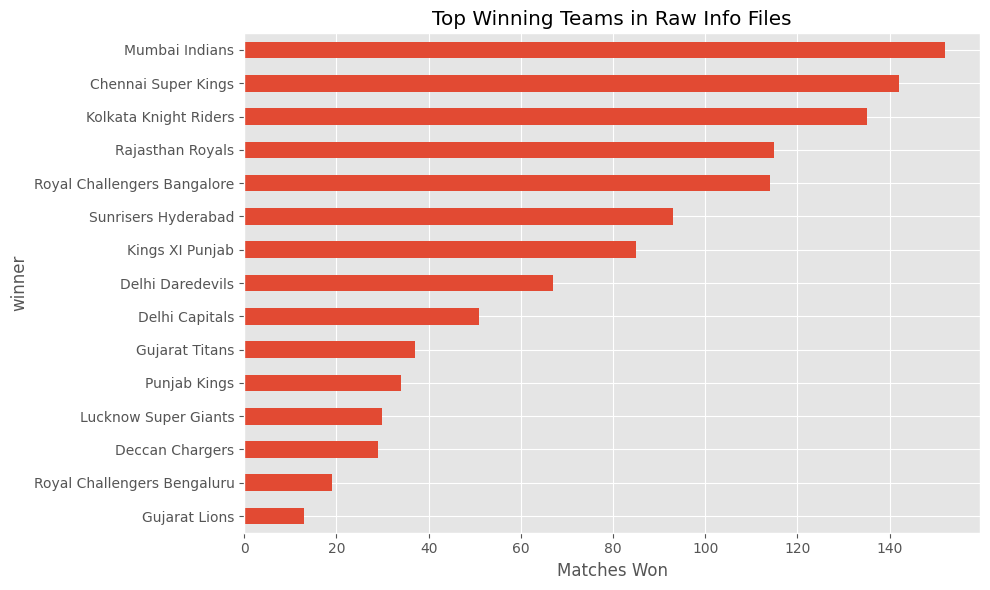

In [18]:
ax = winner_counts.sort_values().plot(kind='barh', figsize=(10, 6), title='Top Winning Teams in Raw Info Files')
ax.set_xlabel('Matches Won')
plt.tight_layout()

## Quick Findings

In [19]:
findings = [
    f"Raw folder contains {len(match_files):,} match CSV files and {len(info_files):,} info CSV files.",
    f"Raw ball-by-ball files contain {int(match_summary['rows'].sum()):,} rows in total.",
    f"Average raw match file size is {match_summary['rows'].mean():.2f} rows.",
    f"Raw season coverage runs from {match_summary['season'].sort_values().iloc[0]} to {match_summary['season'].sort_values().iloc[-1]}.",
    f"Toss decision is 'field' in {100 * (info_df['toss_decision'] == 'field').mean():.2f}% of info files.",
    f"Winner is missing in {int(info_df['winner'].isna().sum())} info files.",
]
pd.Series(findings, name='summary')

0    Raw folder contains 1,172 match CSV files and ...
1    Raw ball-by-ball files contain 278,876 rows in...
2          Average raw match file size is 237.95 rows.
3       Raw season coverage runs from 2007/08 to 2026.
4    Toss decision is 'field' in 65.44% of info files.
5                  Winner is missing in 23 info files.
Name: summary, dtype: object